In [2]:
import geopandas as gpd
import pandas as pd
import numpy as np

In [97]:
# Load your 1-degree grid shapefile
grids = gpd.read_file("/mnt/warehouse/shifting_cultivation/111_result/treeloss/treeloss_sc_merged_mar13.gpkg")

# Make sure the tree loss column exists (2015-2020 sum)
# Example: sc_recent_loss already calculated
# grids['sc_recent_loss'] = grids[['loss_2015', 'loss_2016', ..., 'loss_2020']].sum(axis=1)

# Compute percentiles
percentiles = np.percentile(grids['total_loss'], [10, 25, 50, 75, 90])
p10, p25, p50, p75, p90 = percentiles

print("Percentiles (10,25,50,75,90):", percentiles)

# Define a new categorical column based on percentiles
def categorize(val):
    if val <= p10:
        return 'Bottom 10%'
    elif val <= p25:
        return '10-25%'
    elif val <= p50:
        return '25-50%'
    elif val <= p75:
        return '50-75%'
    elif val <= p90:
        return '75-90%'
    else:
        return 'Top 10%'

grids['loss_category'] = grids['total_loss'].apply(categorize)

# Save to a new shapefile (or geopackage) for QGIS
grids.to_file("/mnt/warehouse/shifting_cultivation/111_result/treeloss/display/treeloss_sc_merged_mar13_percentiles.gpkg")

Percentiles (10,25,50,75,90): [0.00000000e+00 1.72549020e-01 2.18588235e+01 9.58117647e+01
 2.25090196e+02]


In [28]:
grids = gpd.read_file("/mnt/warehouse/shifting_cultivation/111_result/treeloss/treeloss_sc_merged_mar13.gpkg")

In [26]:
zero_count = (grids['total_loss'] == 0).sum()
total_count = len(grids)

zero_percent = zero_count / total_count * 100

print("Zero tree loss grids:", zero_count)
print("Percentage:", round(zero_percent,2), "%")

Zero tree loss grids: 250716
Percentage: 13.95 %


In [29]:
percentiles = np.percentile(grids['total_loss'], [25, 50, 75, 90])

p25, p50, p75, p90 = percentiles

print("Percentiles:", percentiles)

Percentiles: [ 12.7254902   67.36470588 167.21960784 295.6       ]


In [30]:
def categorize(val):

    if val == 0:
        return "No tree loss"

    elif val <= p25:
        return "Low activity"

    elif val <= p50:
        return "Moderate activity"

    elif val <= p75:
        return "High activity"

    elif val <= p90:
        return "Very high activity"

    else:
        return "Hotspots"

grids['activity_class'] = grids['total_loss'].apply(categorize)

In [31]:
# Save to a new shapefile (or geopackage) for QGIS
grids.to_file("/mnt/warehouse/shifting_cultivation/111_result/treeloss/display/treeloss_sc_merged_mar13_activities.gpkg")

In [3]:
grids = gpd.read_file("/mnt/warehouse/shifting_cultivation/111_result/treeloss/display/treeloss_sc_merged_mar13_activities.gpkg")

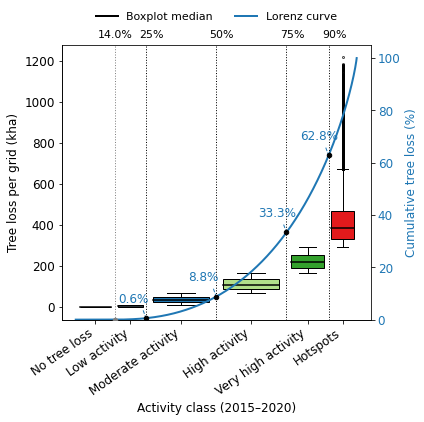

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# --- Boxplot data ---
activity_classes = [
    "No tree loss",
    "Low activity",
    "Moderate activity",
    "High activity",
    "Very high activity",
    "Hotspots"
]

counts = grids['activity_class'].value_counts().reindex(activity_classes)
total_grids = len(grids)

# Positions for boxplot aligned with cumulative % of grids
positions = []
start = 0
for cls in activity_classes:
    end = start + counts[cls] / total_grids * 100
    positions.append((start + end)/2)  # center
    start = end

data = [grids.loc[grids['activity_class']==cls, 'total_loss'].values for cls in activity_classes]

# --- Lorenz curve data ---
sorted_loss = np.sort(grids['total_loss'])
cum_grids = np.arange(1, len(sorted_loss)+1) / len(sorted_loss) * 100
cum_loss_pct = np.cumsum(sorted_loss) / np.sum(sorted_loss) * 100  # % of total tree loss

zero_count = (grids['total_loss'] == 0).sum()
zero_percent = zero_count / len(grids) * 100
percentiles = [25, 50, 75, 90]

# --- Plot ---
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 12})
fig, ax = plt.subplots(figsize=(6,6))

# Boxplot
bp = ax.boxplot(data, positions=positions, widths=[c/total_grids*80 for c in counts.values],
                patch_artist=True, showfliers=True, flierprops=dict(marker='o', markersize=2, alpha=0.7))

colors = ["#d9d9d9", "#a6cee3", "#1f78b4", "#b2df8a", "#33a02c", "#e31a1c"]
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_edgecolor("black")
for whisker in bp['whiskers']:
    whisker.set_color("black")
for cap in bp['caps']:
    cap.set_color("black")
for median in bp['medians']:
    median.set_color("black")
    median.set_linewidth(1.5)

# X-axis labels
ax.set_xticks(positions)
ax.set_xticklabels(activity_classes, rotation=35, ha='right', fontsize=12)
ax.set_xlabel("Activity class (2015–2020)", fontsize=12)
ax.set_ylabel("Tree loss per grid (kha)", fontsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# --- Lorenz curve on twin y-axis ---
ax2 = ax.twinx()
ax2.plot(cum_grids, cum_loss_pct, color="#1f77b4", linewidth=2, label="Lorenz curve")
ax2.set_ylabel("Cumulative tree loss (%)", fontsize=12, color="#1f77b4")
ax2.tick_params(axis='y', labelcolor="#1f77b4", labelsize=12)
ax2.set_ylim(0, 105)

# --- Percentile and zero-loss points and labels with leader lines ---
for p in [zero_percent] + percentiles:
    if p == zero_percent:
        x = zero_percent
        y = 0
        top_label = f"{round(zero_percent,1)}%"
        color_line = 'gray'
        marker_color = 'gray'
        label_offset = (0, 3)
        callout_y = y + 2
    else:
        idx = int(p/100 * len(sorted_loss))
        x = cum_grids[idx]
        y = cum_loss_pct[idx]
        top_label = f"{p}%"
        color_line = 'black'
        marker_color = 'black'
        label_offset = (2, 3)
        callout_y = y + 2
    
    # Vertical line
    ax2.axvline(x, linestyle=":", linewidth=1, color=color_line)
    
    # Dot marker on curve
    ax2.scatter(x, y, color=marker_color, s=20, zorder=5)
    
    # Percentile label on top
    ax2.text(x + label_offset[0], 104 + label_offset[1], top_label, ha='center', va='bottom', fontsize=11)
    
    # Cumulative tree loss label on curve
    if p != zero_percent:
        label_x = x + 2
        label_y = y + 6
        ax2.text(label_x-12, label_y, f"{y:.1f}%", fontsize=12, color="#1f77b4")
        # Leader line from label to point
        ax2.plot([label_x-3, x], [label_y-3, y], color="#1f77b4", lw=1, linestyle="--")

# --- Legend above the plot ---
handles = [
    plt.Line2D([0], [0], color='black', lw=2, label='Boxplot median'),
    plt.Line2D([0], [0], color="#1f77b4", lw=2, label='Lorenz curve')
]
ax.legend(handles=handles, frameon=False, loc='lower center', bbox_to_anchor=(0.5, 1.05), ncol=2, fontsize=11)

plt.tight_layout()
#plt.savefig("/mnt/warehouse/shifting_cultivation/111_result/figure/tree_loss/panelB_boxplot_Lorenz_dot_callout.png", dpi=600)
plt.show()

In [ ]:
n = len(sorted_loss)
idx90 = int(0.9 * n)

bottom90_loss_pct = cum_loss_pct[idx90 - 1]
top10_loss_pct = 100 - bottom90_loss_pct

print("Bottom 90% of grids account for:", round(bottom90_loss_pct, 2), "% of tree loss")
print("Top 10% of grids account for:", round(top10_loss_pct, 2), "% of tree loss")

In [ ]:
region_stats = (
    grids.groupby(['region','activity_class'])
    .size()
    .unstack(fill_value=0)
)

region_percent = region_stats.div(region_stats.sum(axis=1), axis=0) * 100

In [ ]:
# Compute percentiles
percentiles = np.percentile(grids['total_loss'], [10, 25, 50, 75, 90])
p10, p25, p50, p75, p90 = percentiles

print("Percentiles (10,25,50,75,90):", percentiles)

# Define a new categorical column based on percentiles
def categorize(val):
    if val <= p10:
        return 'Bottom 10%'
    elif val <= p25:
        return '10-25%'
    elif val <= p50:
        return '25-50%'
    elif val <= p75:
        return '50-75%'
    elif val <= p90:
        return '75-90%'
    else:
        return 'Top 10%'

grids['loss_category'] = grids['total_loss'].apply(categorize)

# Save to a new shapefile (or geopackage) for QGIS
#grids.to_file("/mnt/warehouse/shifting_cultivation/111_result/treeloss/display/treeloss_mix_merged_mar13_percentiles.gpkg")

In [20]:
order = ['Bottom 10%', '10-25%', '25-50%', '50-75%', '75-90%', 'Top 10%']
counts = grids['loss_category'].value_counts().reindex(order)

print(counts)

Bottom 10%    256481
10-25%        189526
25-50%        438518
50-75%        442251
75-90%        265358
Top 10%       176900
Name: loss_category, dtype: int64


In [15]:
total_loss = grids['total_loss'].sum()

In [16]:
top10_loss = grids[grids['loss_category'] == 'Top 10%']['total_loss'].sum()

In [18]:
percentage = (top10_loss / total_loss) * 100
print(percentage)

37.42264212604609
